# ML Fundamentals #3: Decision Tree

## Breast Cancer Classification using Decision Tree

This project implements a Decision Tree Classifier using the Breast Cancer Wisconsin Diagnostic Dataset.

The notebook covers:

- Data Loading
- Dataset Understanding
- Exploratory Data Analysis
- Data Preprocessing
- Decision Tree Training
- Tree Visualization
- Model Evaluation
- Feature Importance
- Model Serialization

In [1]:
# Import required libraries for data analysis, visualization, modeling, and saving outputs

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

In [2]:
# Create output directories for storing figures and tables

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

print("Output directories created successfully.")

Output directories created successfully.


## 2. Loading the Dataset

This project uses the Breast Cancer Wisconsin Diagnostic Dataset from Scikit-learn.

The dataset contains numerical measurements computed from digitized images of breast cell nuclei. The target variable classifies tumors as either Malignant or Benign.

In [3]:
# Load the Breast Cancer Wisconsin dataset

cancer = load_breast_cancer(as_frame=True)

df = cancer.frame

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Save a preview of the dataset

df.head(10).to_csv(
    "outputs/tables/dataset_preview.csv",
    index=False
)

In [5]:
# Display dataset dimensions

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 569
Columns: 31


### Insights

- The dataset has been successfully loaded.
- Each row represents one tumor sample.
- The dataset contains numerical features describing cell nucleus characteristics.
- The target variable represents binary tumor classification.

## 3. Understanding the Dataset

Before training the Decision Tree model, we examine the dataset structure, feature information, missing values, statistical summary, and target class distribution.

In [6]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [7]:
# Generate descriptive statistics

summary = df.describe().T

summary

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [8]:
# Save descriptive statistics

summary.to_csv(
    "outputs/tables/dataset_summary.csv"
)

In [9]:
# Check for missing values

missing = df.isnull().sum()

missing

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [10]:
# Save missing value summary

missing.to_csv(
    "outputs/tables/missing_values.csv"
)

In [11]:
# Display target class distribution

df["target"].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [12]:
# Save target class distribution

target_distribution = df["target"].value_counts().reset_index()

target_distribution.columns = ["Class", "Count"]

target_distribution.to_csv(
    "outputs/tables/target_distribution.csv",
    index=False
)

### Insights

- The dataset consists entirely of numerical features.
- No missing values are present.
- The target variable contains two classes:
  - **0 → Malignant**
  - **1 → Benign**
- The dataset is clean and suitable for Decision Tree classification.

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps identify patterns, feature distributions, and relationships within the dataset before training the Decision Tree model.

This section includes class distribution, feature distributions, and correlation analysis.

In [13]:
# Display the first five records

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


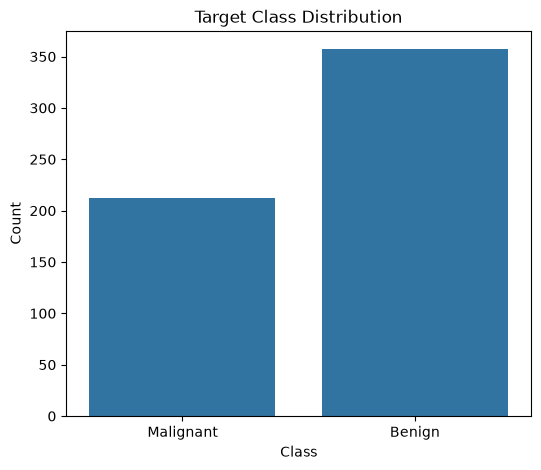

In [14]:
# Plot the target class distribution

plt.figure(figsize=(6,5))

sns.countplot(x="target", data=df)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.xticks([0,1],["Malignant","Benign"])

plt.savefig(
    "outputs/figures/target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- The dataset contains two target classes.
- The class distribution is reasonably balanced.
- Decision Trees can effectively learn from this dataset without additional balancing techniques.

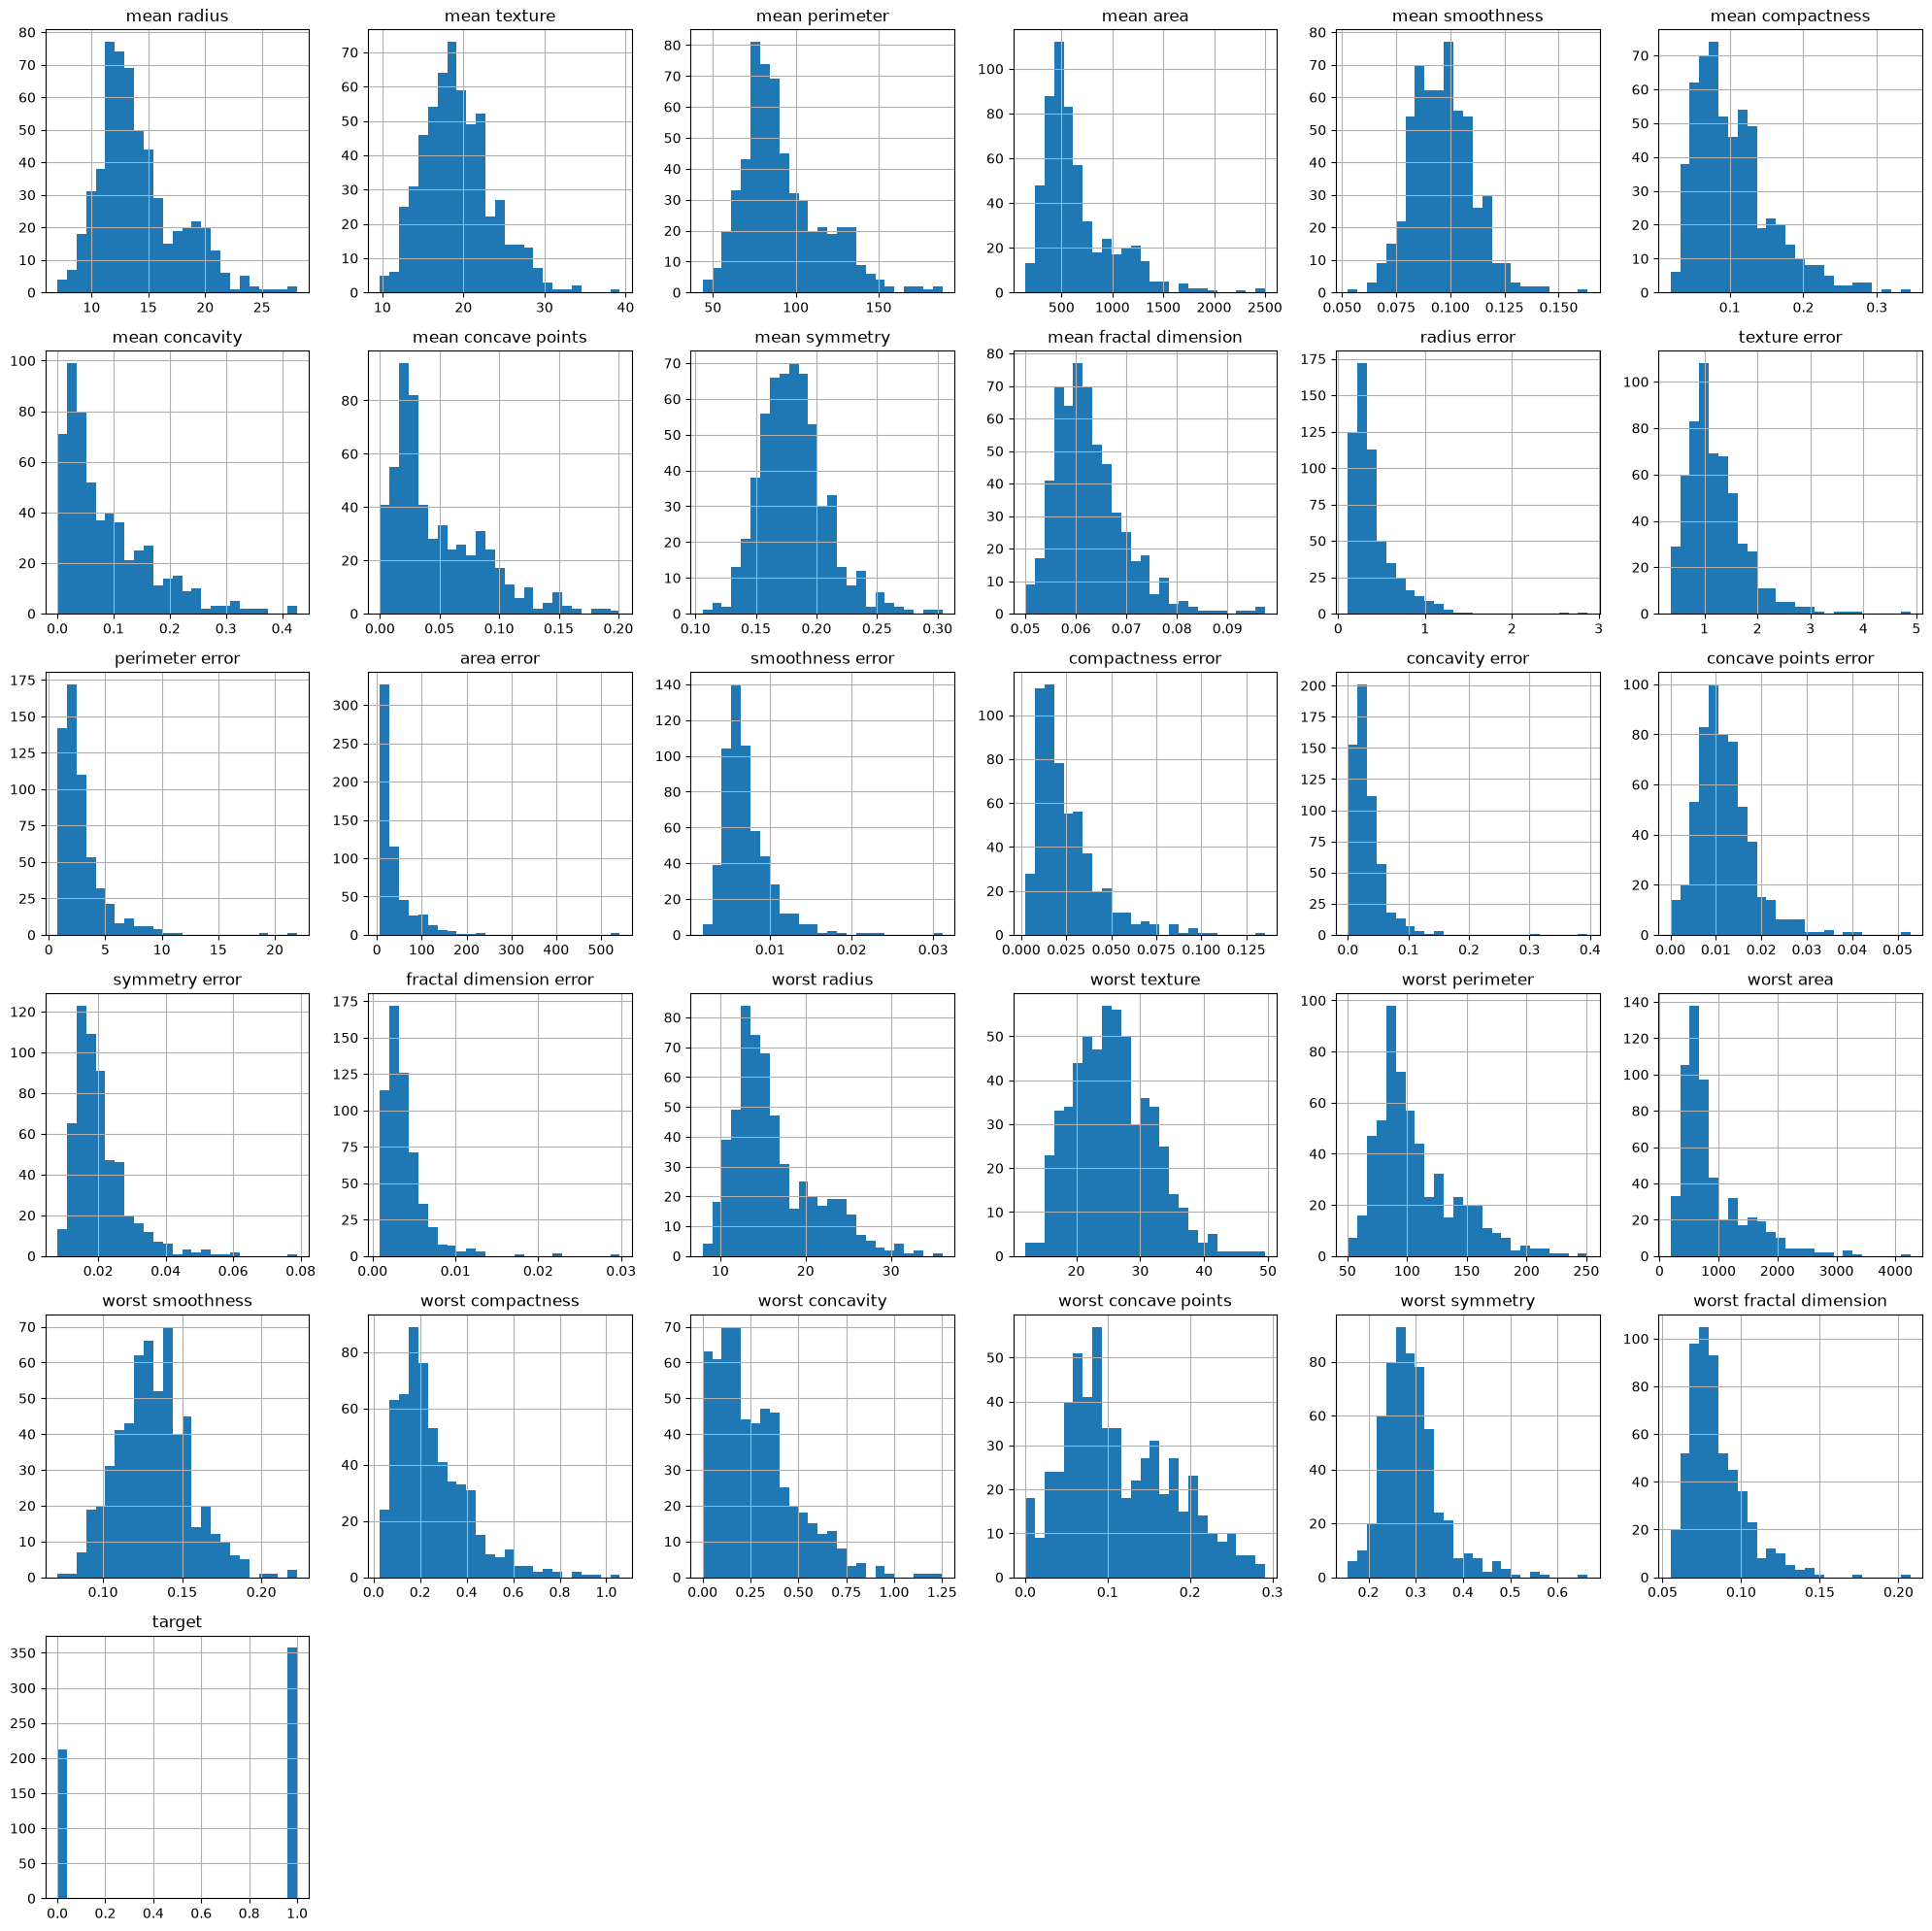

In [15]:
# Plot feature distributions

df.hist(figsize=(20,20), bins=25)

plt.tight_layout()

plt.savefig(
    "outputs/figures/feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- Feature distributions vary considerably across variables.
- Several predictors exhibit skewed distributions.
- Decision Trees do not require feature scaling, making them robust to varying feature ranges.

In [16]:
# Compute the feature correlation matrix

correlation = df.corr()

correlation

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,-0.730029
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,-0.415185
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,-0.742636
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,-0.708984
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,-0.358560
mean compactness,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,-0.596534
mean concavity,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,-0.696360
mean concave points,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,-0.776614
mean symmetry,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,-0.330499
mean fractal dimension,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297,0.012838


In [17]:
# Save the correlation matrix

correlation.to_csv(
    "outputs/tables/correlation_matrix.csv"
)

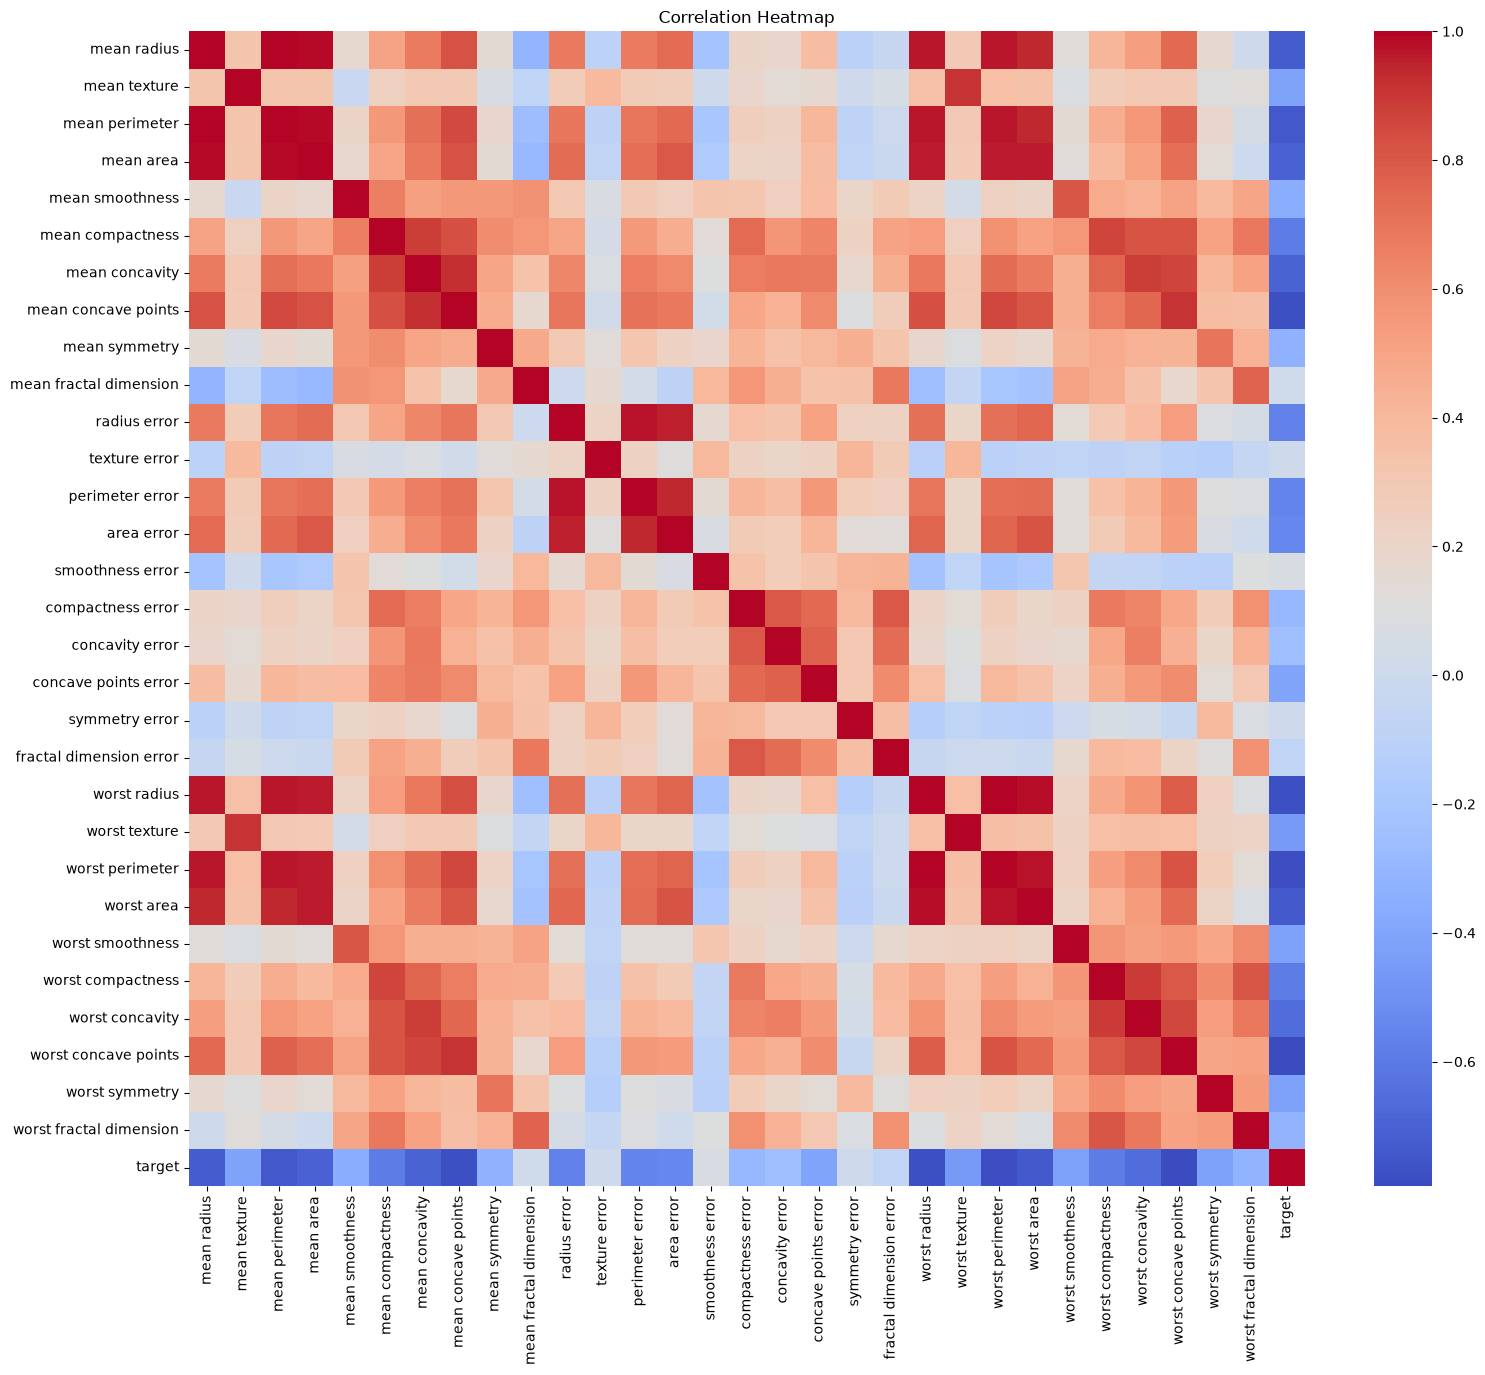

In [18]:
# Plot the correlation heatmap

plt.figure(figsize=(18,15))

sns.heatmap(
    correlation,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "outputs/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- Strong correlations exist among several features.
- Decision Trees naturally select informative features during splitting and are less affected by multicollinearity compared to linear models.

# 5. Data Preprocessing

Before training the Decision Tree model, the dataset is prepared by separating the features and target variable and splitting the data into training and testing sets.

Unlike Logistic Regression, Decision Trees do **not** require feature scaling.

In [19]:
# Separate the features and target variable

X = df.drop("target", axis=1)
y = df["target"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (569, 30)
Target Shape : (569,)


In [20]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (455, 30)
Testing Features : (114, 30)
Training Labels : (455,)
Testing Labels : (114,)


In [21]:
# Save sample training data

X_train.head().to_csv(
    "outputs/tables/training_features.csv",
    index=False
)

y_train.head().to_csv(
    "outputs/tables/training_labels.csv",
    index=False
)

### Insights

- The dataset has been divided into training and testing sets using an 80:20 split.
- Stratified sampling preserves the original class distribution.
- Decision Trees operate directly on the original feature values without requiring normalization or standardization.
- The processed dataset is ready for model training.

# 6. Model Training

In this section, a Decision Tree Classifier is trained using the training dataset.

The model recursively learns decision rules that split the feature space into regions corresponding to the target classes.

In [22]:
# Train the Decision Tree model

model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    max_depth=4
)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### Insights

- The Decision Tree model has been successfully trained.
- The model learns a hierarchy of decision rules from the training data.
- The trained model is now ready to classify unseen observations.

# 7. Prediction

The trained Decision Tree model is used to predict both the target class and the probability of each class for unseen test samples.

In [23]:
# Predict the target labels

y_pred = model.predict(X_test)

y_pred[:10]

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0])

In [24]:
# Predict class probabilities

y_prob = model.predict_proba(X_test)

y_prob[:10]

array([[1.        , 0.        ],
       [0.00772201, 0.99227799],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.00772201, 0.99227799],
       [0.00772201, 0.99227799],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ]])

In [25]:
# Save sample predictions

predictions = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted": y_pred
})

predictions.head(20).to_csv(
    "outputs/tables/sample_predictions.csv",
    index=False
)

### Insights

- The model successfully predicts the tumor class for unseen samples.
- Class probabilities indicate the confidence associated with each prediction.
- These probabilities will be used during ROC-AUC evaluation.

# 8. Model Evaluation

The trained Decision Tree model is evaluated using standard classification metrics to measure its predictive performance on unseen data.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- Classification Report

In [26]:
# Calculate model evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob[:,1])

metrics = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

metrics

,Metric,Value
0,Accuracy,0.938596
1,Precision,0.957746
2,Recall,0.944444
3,F1 Score,0.951049
4,ROC-AUC,0.934193


In [27]:
# Save evaluation metrics

metrics.to_csv(
    "outputs/tables/evaluation_metrics.csv",
    index=False
)

### Insights

- Accuracy measures overall prediction performance.
- Precision measures the correctness of positive predictions.
- Recall measures how effectively malignant tumors are identified.
- F1 Score balances Precision and Recall.
- ROC-AUC summarizes the model's ability to distinguish between classes.

In [28]:
# Generate the confusion matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[39,  3],
       [ 4, 68]])

In [29]:
# Save the confusion matrix

pd.DataFrame(
    cm,
    index=["Actual Malignant","Actual Benign"],
    columns=["Predicted Malignant","Predicted Benign"]
).to_csv(
    "outputs/tables/confusion_matrix.csv"
)

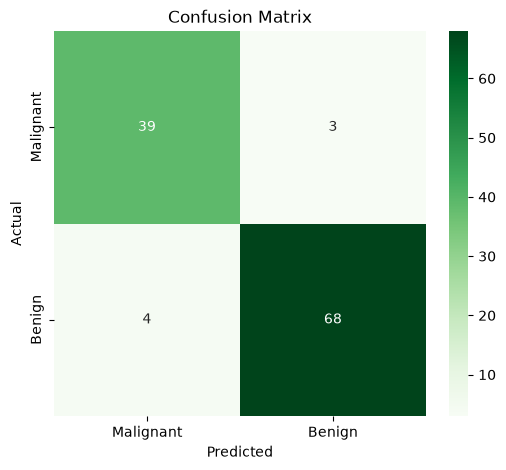

In [30]:
# Plot the confusion matrix

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Malignant","Benign"],
    yticklabels=["Malignant","Benign"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "outputs/figures/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- The confusion matrix summarizes correct and incorrect classifications.
- Higher diagonal values indicate stronger predictive performance.
- False Positives and False Negatives reveal the model's classification errors.

In [31]:
# Generate the classification report

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
0,0.906977,0.928571,0.917647,42.000000
1,0.957746,0.944444,0.951049,72.000000
accuracy,0.938596,0.938596,0.938596,0.938596
macro avg,0.932362,0.936508,0.934348,114.000000
weighted avg,0.939042,0.938596,0.938743,114.000000


In [32]:
# Save the classification report

report_df.to_csv(
    "outputs/tables/classification_report.csv"
)

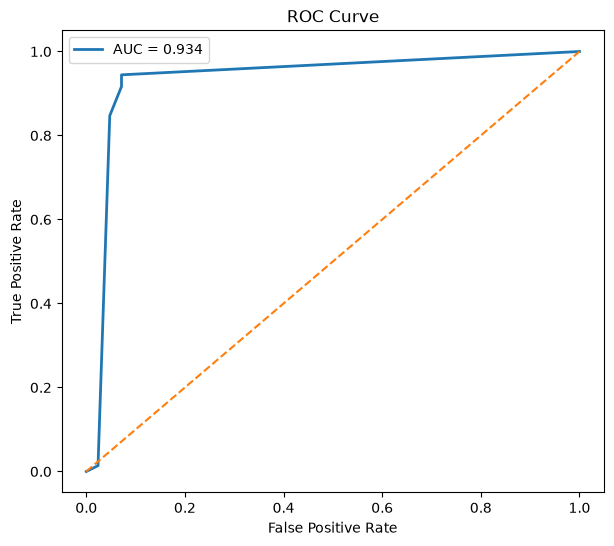

In [33]:
# Plot the ROC curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob[:,1]
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "outputs/figures/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- The ROC Curve visualizes the trade-off between sensitivity and specificity.
- A higher ROC-AUC score indicates stronger classification capability.
- The Decision Tree demonstrates effective separation between malignant and benign classes.

# 9. Decision Tree Visualization

Visualizing the trained Decision Tree provides insight into the sequence of decision rules learned from the training data.

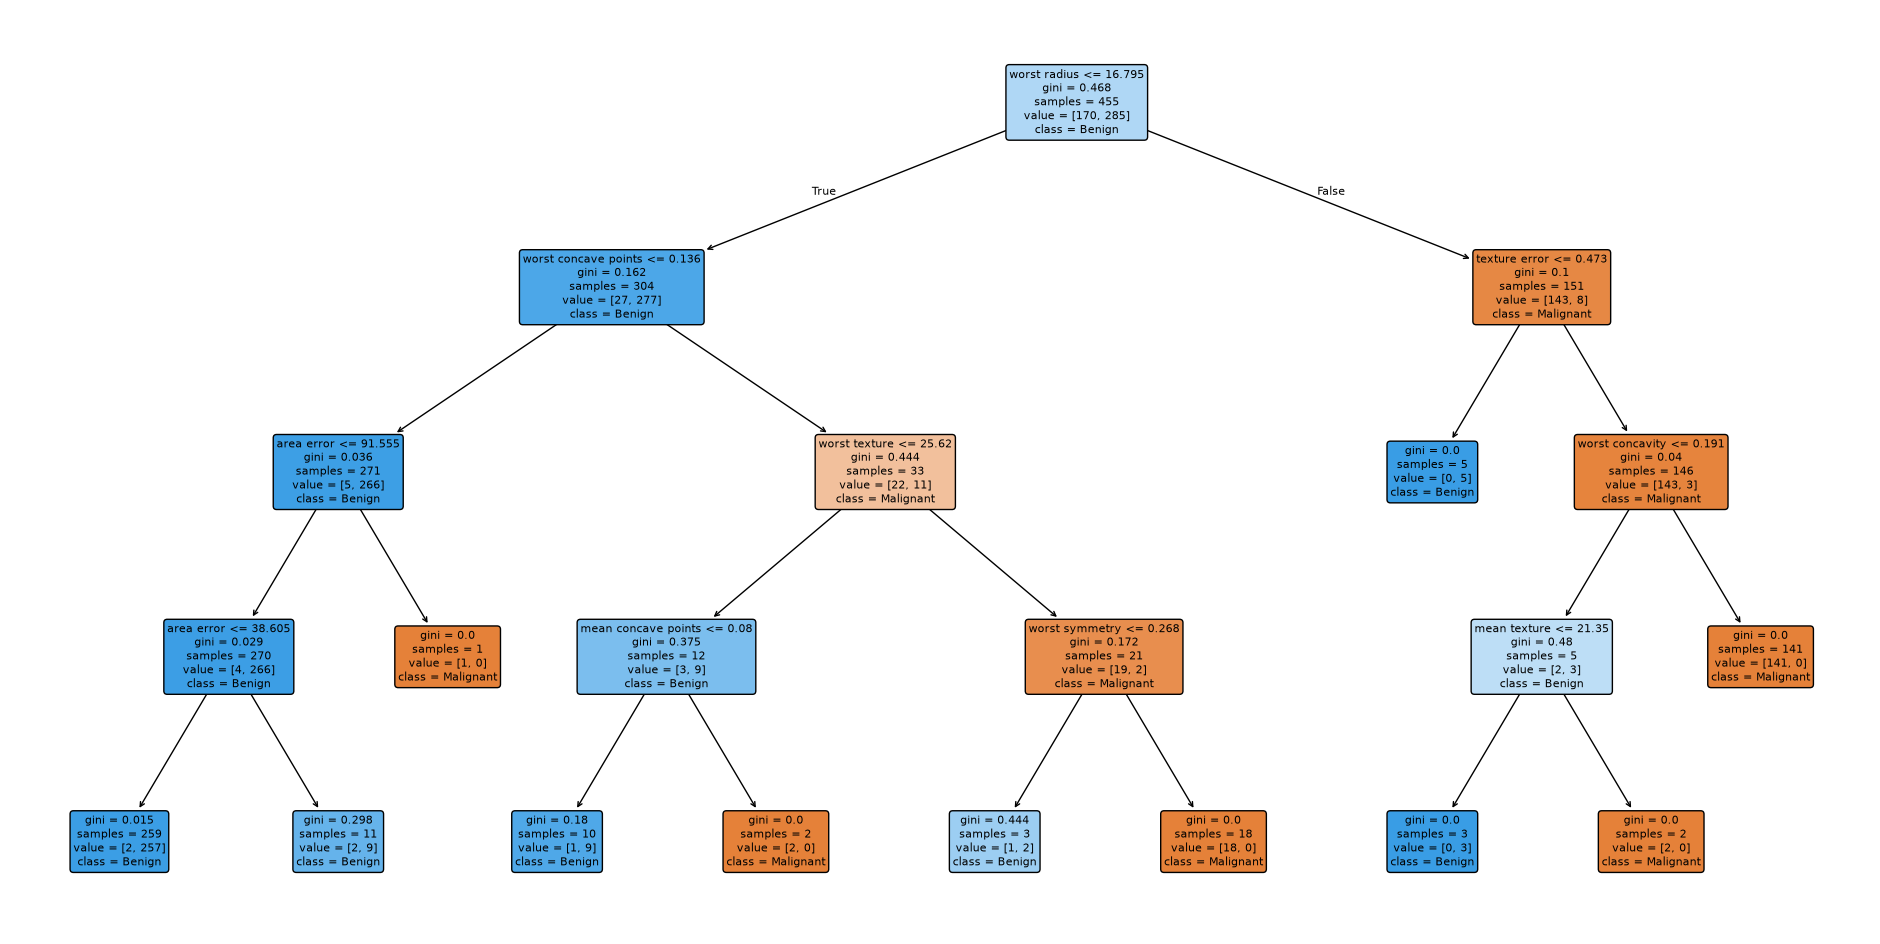

In [34]:
# Visualize the trained Decision Tree

plt.figure(figsize=(24,12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Malignant","Benign"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.savefig(
    "outputs/figures/decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- The Decision Tree illustrates the hierarchy of feature-based decisions.
- Internal nodes represent feature thresholds.
- Leaf nodes correspond to the final predicted class.

# 10. Feature Importance

Decision Trees estimate feature importance based on the reduction in impurity achieved by each feature during splitting.

In [35]:
# Compute feature importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
20,worst radius,0.733548
27,worst concave points,0.122028
11,texture error,0.045785
21,worst texture,0.032319
26,worst concavity,0.017161
7,mean concave points,0.013327
13,area error,0.012704
1,mean texture,0.011846
28,worst symmetry,0.011282
3,mean area,0.000000


In [36]:
# Save feature importance

importance.to_csv(
    "outputs/tables/feature_importance.csv",
    index=False
)

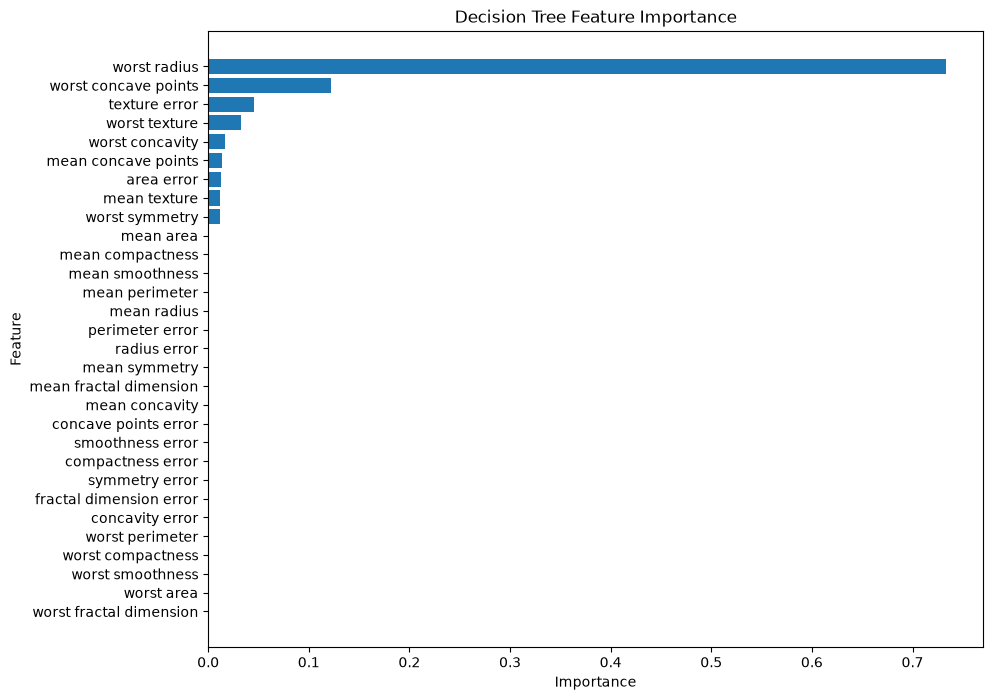

In [37]:
# Plot feature importance

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.savefig(
    "outputs/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insights

- Features with higher importance contribute more significantly to the model's decisions.
- Decision Trees naturally perform feature selection during training.

# 11. Saving the Model

The trained Decision Tree model is serialized for future inference without retraining.

In [38]:
# Save the trained Decision Tree model

joblib.dump(
    model,
    "models/decision_tree.pkl"
)

print("Model saved successfully.")

Model saved successfully.


# 12. Conclusion

This project successfully implemented a Decision Tree Classifier using the Breast Cancer Wisconsin dataset.

The workflow included:

- Data Loading
- Exploratory Data Analysis
- Data Preprocessing
- Model Training
- Prediction
- Model Evaluation
- Decision Tree Visualization
- Feature Importance Analysis
- Model Serialization

The Decision Tree provides an interpretable classification model capable of accurately distinguishing between malignant and benign tumors.